In [5]:
import pandas as pd

data = {
    'Order_ID':   ['ORD001','ORD002','ORD003','ORD004','ORD005',
                   'ORD006','ORD007','ORD008','ORD009','ORD010'],
    'Product':    ['Laptop','Rice Bag','Headphones','Notebook','Blender',
                   'Rice Bag','Laptop','Notebook','Blender','Headphones'],
    'Category':   ['Electronics','Food','Electronics','Stationery','Appliances',
                   'Food','Electronics','Stationery','Appliances','Electronics'],
    'Region':     ['North','South','East','West','North',
                   'East','South','North','West','North'],
    'Units_Sold': [5, 30, 12, 50, 8, 20, 3, 80, 6, 15],
    'Unit_Price': [850.00, 12.50, 45.00, 3.20, 65.00,
                   12.50, 850.00, 3.20, 65.00, 45.00],
    'Month':      ['January','January','February','February','March',
                   'March','April','April','May','May']
}

df = pd.DataFrame(data)
print(df)

  Order_ID     Product     Category Region  Units_Sold  Unit_Price     Month
0   ORD001      Laptop  Electronics  North           5       850.0   January
1   ORD002    Rice Bag         Food  South          30        12.5   January
2   ORD003  Headphones  Electronics   East          12        45.0  February
3   ORD004    Notebook   Stationery   West          50         3.2  February
4   ORD005     Blender   Appliances  North           8        65.0     March
5   ORD006    Rice Bag         Food   East          20        12.5     March
6   ORD007      Laptop  Electronics  South           3       850.0     April
7   ORD008    Notebook   Stationery  North          80         3.2     April
8   ORD009     Blender   Appliances   West           6        65.0       May
9   ORD010  Headphones  Electronics  North          15        45.0       May


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

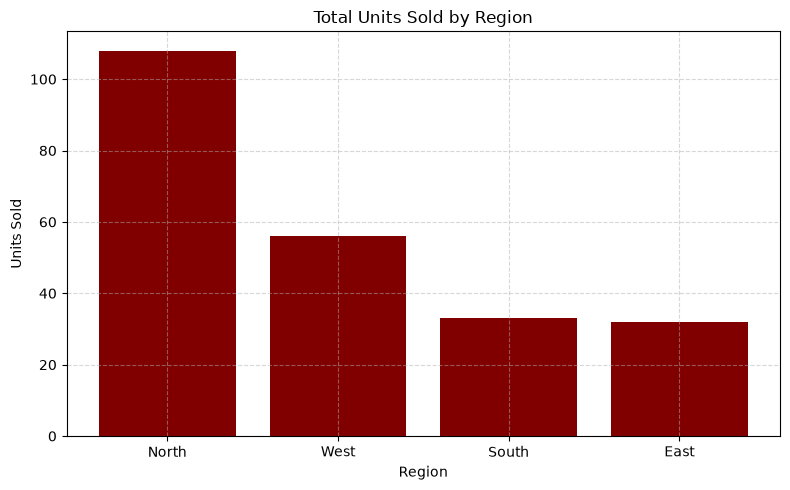

In [16]:
region_sales = df.groupby("Region")["Units_Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values, color="maroon")
plt.title("Total Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Units Sold")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Insight:

The North region recorded the highest units sold with 108 units, followed by West with 56, South with 33 and East with 32.

Recommendation:

The business should prioritise stock availability and marketing efforts in the North region to capitalise on existing high demand, while investigating why East and South are underperforming to identify growth opportunities there.

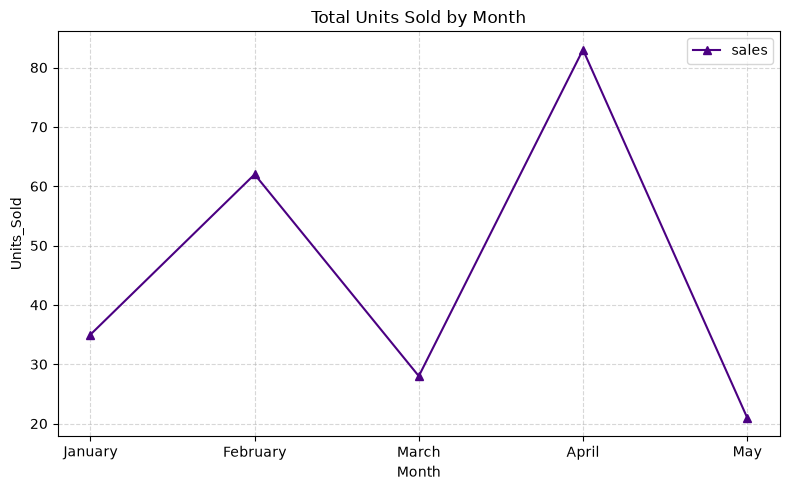

In [15]:
month_order = ["January", "February", "March", "April", "May"]
monthly_sales = df.groupby("Month")["Units_Sold"].sum().reindex(month_order)

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index,monthly_sales.values, marker = "^", label = "sales", color = "indigo")
plt.title("Total Units Sold by Month")
plt.xlabel("Month")
plt.ylabel("Units_Sold")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Insight:

April recorded the highest units sold with 83 units, while sales fluctuated throughout the 5 months. Rising in February, dropping in March, peaking in April and declining again in May.

Recommendation:

The business should investigate what drove the April spike. Check whether it was a promotion, seasonal demand or external factor and replicate those conditions in slower months like March and May to stabilise sales performance.

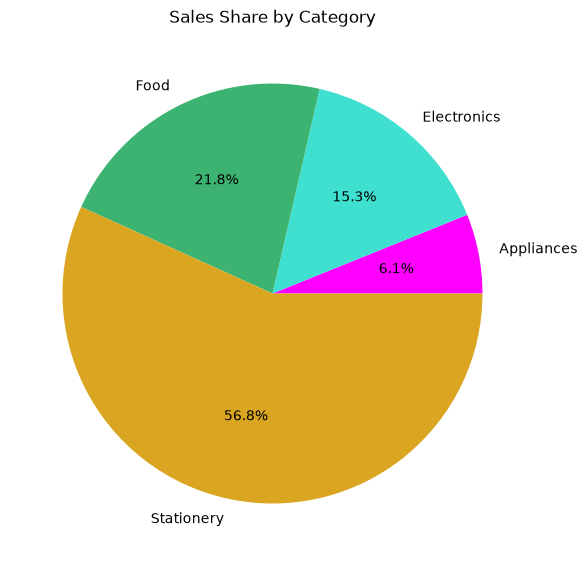

In [22]:
category_sales = df.groupby("Category")["Units_Sold"].sum()

plt.figure(figsize=(6, 6))
plt.pie(category_sales.values, labels=category_sales.index, autopct="%1.1f%%", 
        colors=["fuchsia","turquoise","mediumseagreen","goldenrod"])
plt.title("Sales Share by Category")
plt.tight_layout()
plt.show()

Insight:

Stationery dominates sales with the highest share of units sold, followed by Food and Electronics, while Appliances recorded the least. This pattern is likely driven by need and affordability. Stationery and food are everyday essentials that are cheap enough for frequent repeat purchases, whereas Electronics and Appliances are higher-ticket items that people buy less often. Price point and necessity are clearly shaping buying behaviour across all four categories.

Recommendation:

The business should investigate what is driving Stationery's strong performance, whether it's price accessibility, repeat purchasing behaviour or seasonal demand like school reopenings and explore whether similar strategies can be applied to boost slower categories like Appliances. For Appliances specifically, the business could consider instalment payment options or promotional bundles to lower the barrier to purchase and drive volume.

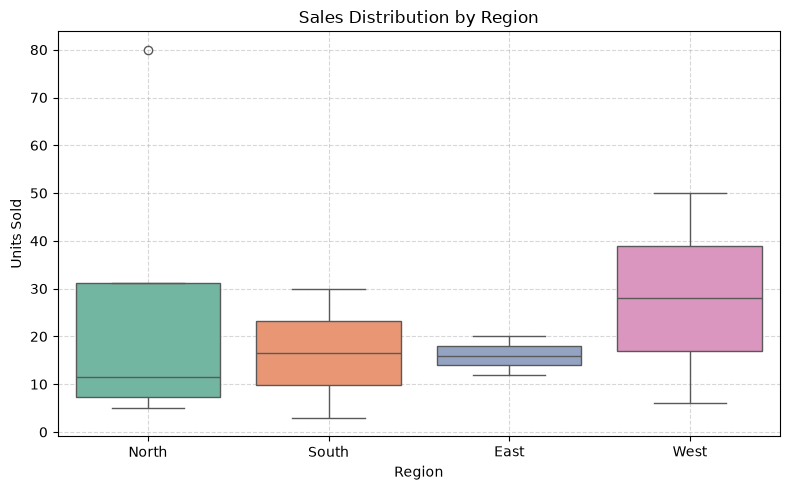

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Region", y="Units_Sold", hue="Region", palette="Set2", legend=False)
plt.title("Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Units Sold")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Insight:

North region shows the most inconsistent sales pattern with the tallest box and an outlier of 80 units in April, driven by the Notebook spike we identified earlier. East region on the other hand has the shortest box, indicating a steady and predictable sales pattern. While North appears impressive in total volume, its inconsistency makes it harder to plan around.

Recommendation:

The business should study East region's sales consistency and understand what drives their steady performance, whether it's customer loyalty, product mix or distribution reliability, and replicate those conditions in other regions. North's April outlier should not be used as a benchmark for planning since it was likely a one-time seasonal event rather than a sustained trend. Reliable consistency like East's is more valuable for long-term business planning than unpredictable spikes.

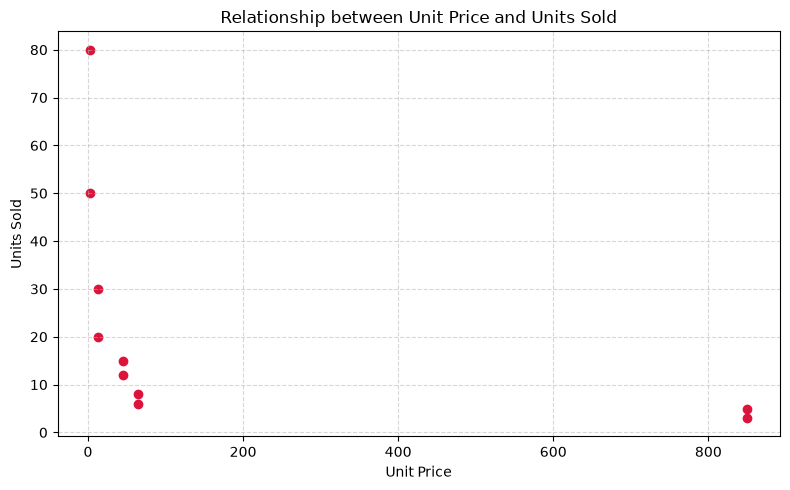

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(x=df["Unit_Price"], y=df["Units_Sold"], color="crimson")
plt.title("Relationship between Unit Price and Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Insight:

The scatter plot reveals a negative correlation between unit price and units sold. Cheaper products recorded higher sales volumes while expensive ones sold fewer units. However, price alone does not tell the full story. Notebooks and Rice Bags sell in high volumes not just because they are affordable but because they are consumable everyday essentials that customers need repeatedly. Laptops on the other hand are one-time purchases regardless of price, meaning demand is driven more by need and purchase frequency than by price sensitivity alone.

Recommendation:

The business should be cautious about assuming that reducing prices on high-ticket items like Laptops will automatically drive volume, since the low sales are likely driven by the nature of the product rather than price alone. A more effective strategy would be to maximise availability and margins on high-frequency consumables like Notebooks and Rice Bags, while positioning Laptops as premium offerings targeting specific customer segments. Further investigation into who is buying Laptops, when and why would give a clearer picture of how to grow sales in that category.